In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("df_transformed.csv")
print("Columns in df_transformed:")
print(df.columns.tolist())
df.head()

Columns in df_transformed:
['valence', 'popularity', 'acousticness', 'loudness', 'duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo', 'explicit', 'key', 'mode', 'time_signature', 'track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']


,valence,popularity,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,0.082296,0.522709,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,False,10,1,3,False,False,True,False
1,1.066102,0.882222,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.100010,-0.467142,False,3,0,4,False,True,False,False
2,1.486579,0.583396,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,False,2,0,4,False,False,False,True
3,0.770855,-1.669934,-0.915276,0.947310,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.079250,-0.727684,False,9,1,4,True,False,False,False
4,-0.098867,0.482969,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.246500,False,4,0,4,False,False,False,True


## K-Means Clustering

In [3]:
# keep original genre columns for evaluation
df_original = df.copy()

# identify genre columns (one-hot encoded)
genre_cols = [col for col in df.columns if col.startswith("track_genre_")]
print(f"Found {len(genre_cols)} genre columns:", genre_cols)

Found 4 genre columns: ['track_genre_indie-pop', 'track_genre_pop', 'track_genre_r-n-b', 'track_genre_synth-pop']


Cluster counts:
 cluster
0    710
2    519
1    502
3    229
Name: count, dtype: int64


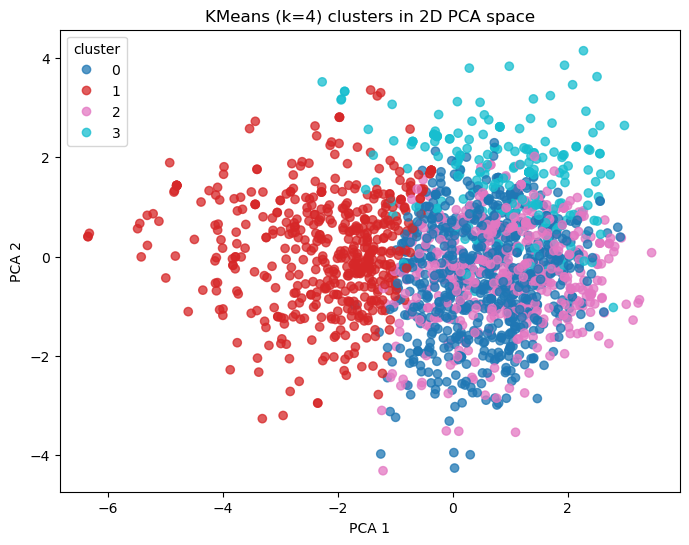

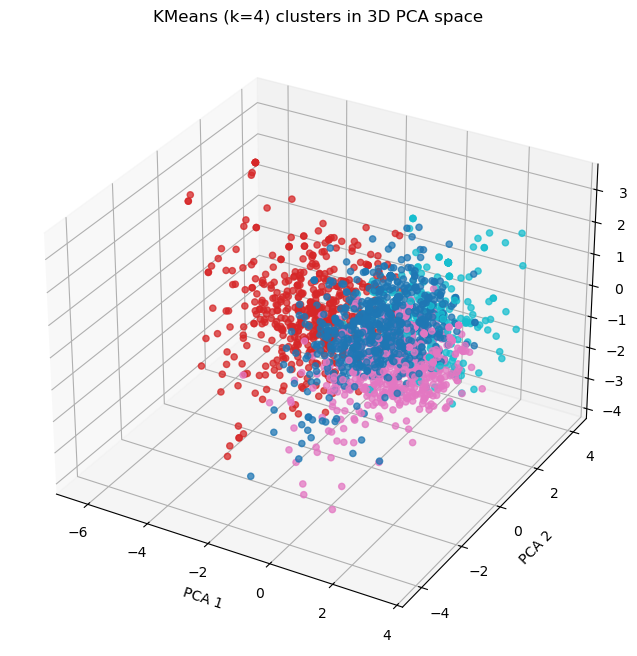

In [4]:
# step 2: drop genres from feature matrix and do clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

k = 4  # we got 4 genres

# drop genre columns for clustering features
df_numeric = df.drop(columns=genre_cols)

# choose numeric columns and scale them
X = df_numeric.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_labels_kmeans = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels_kmeans
print("Cluster counts:\n", df['cluster'].value_counts())

# 2D PCA plot for cluster visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_kmeans, cmap='tab10', alpha=0.75)
plt.title(f"KMeans (k={k}) clusters in 2D PCA space")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title='cluster')
plt.show()

# 3D PCA plot for cluster visualization
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=cluster_labels_kmeans, cmap='tab10', alpha=0.75)
ax.set_title(f"KMeans (k={k}) clusters in 3D PCA space")
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

## DBSCAN clustering

Cluster counts:
 cluster_dbscan
-1    811
 1    729
 0    388
 3     17
 2     15
Name: count, dtype: int64


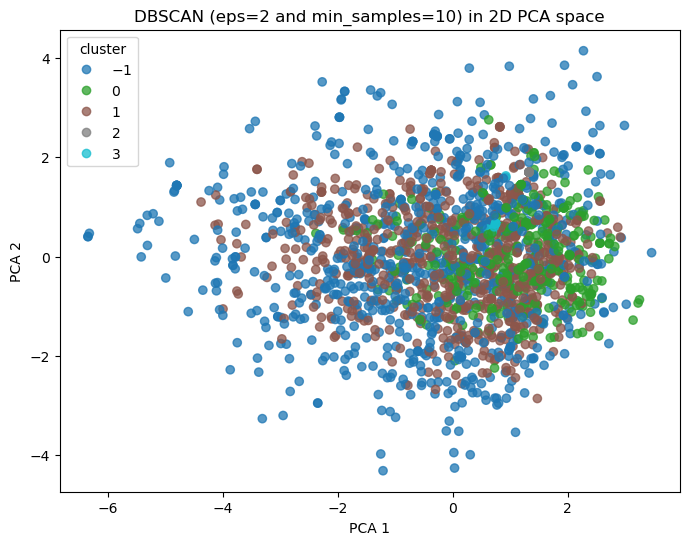

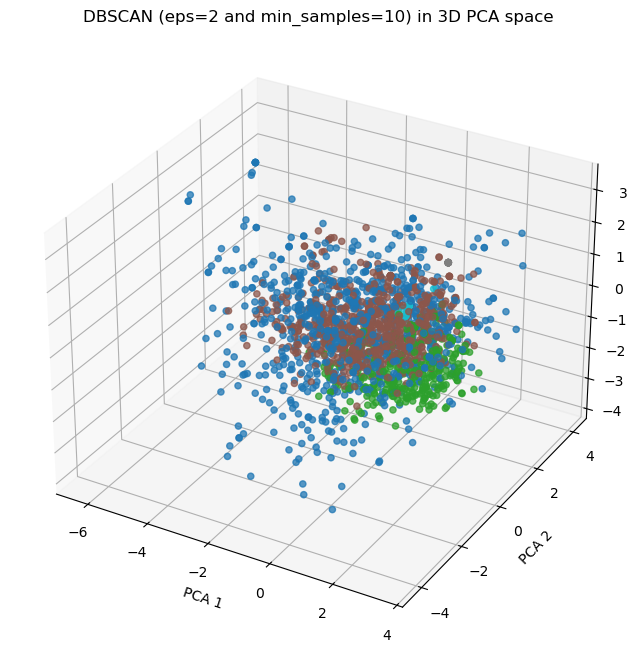

In [5]:
from sklearn.cluster import DBSCAN

# Configure two most important parameters: 
# eps = "radius of the circle for scanning"
# min_samples = "how many points in the neighbourhood in order to call it a core point"
eps = 2
min_samples = 10
dbscan = DBSCAN(eps=eps, min_samples=min_samples)

# use same X_scaled as in KMeans
# fit DBSCAN
cluster_labels_dbscan = dbscan.fit_predict(X_scaled)

# Continue in a same way than with KMeans

df['cluster_dbscan'] = cluster_labels_dbscan
print("Cluster counts:\n", df['cluster_dbscan'].value_counts())

# 2D PCA plot for cluster visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels_dbscan, cmap='tab10', alpha=0.75)
plt.title(f"DBSCAN (eps={eps} and min_samples={min_samples}) in 2D PCA space")
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title='cluster')
plt.show()

# 3D PCA plot for cluster visualization
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=cluster_labels_dbscan, cmap='tab10', alpha=0.75)
ax.set_title(f"DBSCAN (eps={eps} and min_samples={min_samples}) in 3D PCA space")
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.show()

In [6]:
# Number of clusters (= unique values -1, as "-1" is labelled as noise)
n_clusters = len(dict.fromkeys(cluster_labels_dbscan))-1
print(f"Cluster class -1 is for noise/outlier points. As can be seen, with DBSCAN with parameters eps={eps} and min_samples={min_samples}, we find {n_clusters} clusters + noise. \n Almost half of the data is noise, indicating DBSCAN may not be the most suitable algorithm for this application.")

Cluster class -1 is for noise/outlier points. As can be seen, with DBSCAN with parameters eps=2 and min_samples=10, we find 4 clusters + noise. 
 Almost half of the data is noise, indicating DBSCAN may not be the most suitable algorithm for this application.


In [7]:
# == Cluster quality against original genre columns from df_transformed ==

# Cannot be done to DBSCAN results, as number of clusters is not predetermined.

# merge cluster assignments with original genre columns
merged = df_original.copy()
merged['cluster'] = cluster_labels_kmeans

# convert one-hot genre columns to genre name
merged['predicted_genre'] = merged[genre_cols].idxmax(axis=1).str.replace("track_genre_", "")

# show composition per cluster
cluster_genre = (
    merged.groupby(["cluster", "predicted_genre"]).size().reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)
print("Cluster vs Genre composition:")
print(cluster_genre)

# compute majority genre accuracy per cluster
cluster_total = cluster_genre.groupby("cluster")["count"].sum().rename("total")
cluster_top = (
    cluster_genre.groupby("cluster").first().rename(columns={"count": "top_count"})
    .reset_index()
    .set_index("cluster")["top_count"]
)
cluster_summary = pd.concat([cluster_total, cluster_top], axis=1)
cluster_summary["cluster_majority_pct"] = cluster_summary["top_count"] / cluster_summary["total"]

print("\nCluster majority genre accuracy:\n", cluster_summary)

# overall purity estimate
total_matches = cluster_summary["top_count"].sum()
purity = total_matches / len(merged)
print(f"\nOverall clustering purity (proxy accuracy): {purity:.4f}")

# view first 100 rows with cluster and genre
print("\n\nFirst 100 rows - cluster vs predicted genre:")
display(merged[["cluster", "predicted_genre"]].head(100))

Cluster vs Genre composition:
    cluster predicted_genre  count
0         0       indie-pop    255
3         0       synth-pop    206
1         0             pop    126
2         0           r-n-b    123
4         1       indie-pop    232
5         1             pop    129
6         1           r-n-b     81
7         1       synth-pop     60
9         2             pop    177
8         2       indie-pop    171
11        2       synth-pop    119
10        2           r-n-b     52
12        3       indie-pop    128
13        3             pop     56
14        3           r-n-b     37
15        3       synth-pop      8

Cluster majority genre accuracy:
          total  top_count  cluster_majority_pct
cluster                                        
0          710        255              0.359155
1          502        232              0.462151
2          519        177              0.341040
3          229        128              0.558952

Overall clustering purity (proxy accuracy): 0.4041


,cluster,predicted_genre
0,0,r-n-b
1,2,pop
2,2,synth-pop
3,3,indie-pop
4,2,synth-pop
...,...,...
95,0,indie-pop
96,2,indie-pop
97,1,indie-pop
98,2,pop



Genre % composition per cluster:
predicted_genre  indie-pop    pop  r-n-b  synth-pop
cluster                                            
0                    35.92  17.75  17.32      29.01
1                    46.22  25.70  16.14      11.95
2                    32.95  34.10  10.02      22.93
3                    55.90  24.45  16.16       3.49


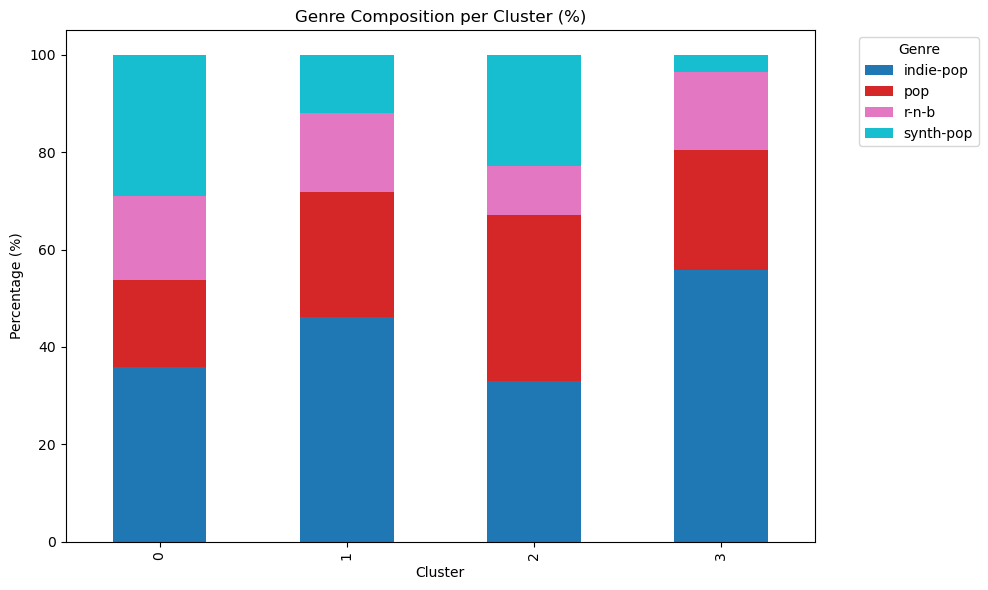

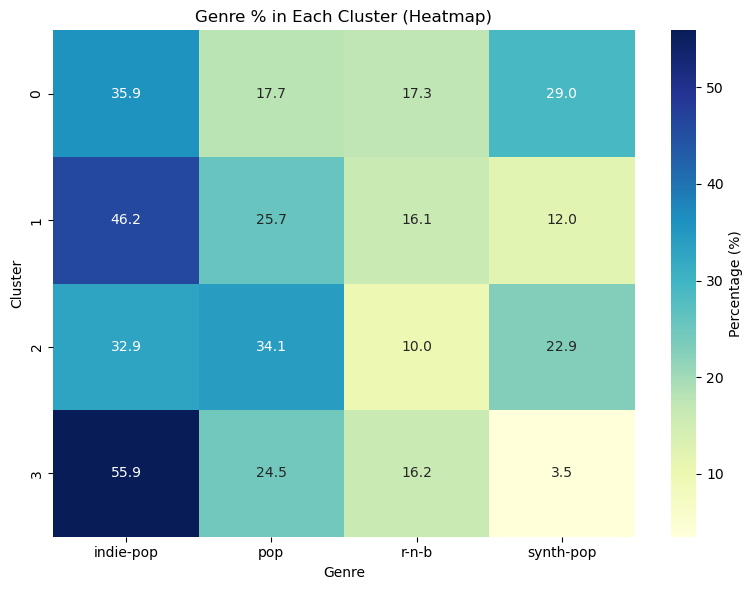


📊 Interpretation:
- Each row represents a cluster
- Each column represents a genre
- High concentration in one genre = good cluster purity
- Mixed percentages = clusters don't cleanly separate genres
- KMeans clustering is in this application more appropriate, as the number of clusters is known


In [8]:
import seaborn as sns

# create pivot table: cluster x genre with percentages
cluster_genre_pivot = cluster_genre.pivot_table(
    index="cluster", 
    columns="predicted_genre", 
    values="count", 
    fill_value=0
)

# convert to percentage per cluster (row-wise normalization)
cluster_genre_pct = cluster_genre_pivot.div(cluster_genre_pivot.sum(axis=1), axis=0) * 100

print("\nGenre % composition per cluster:")
print(cluster_genre_pct.round(2))

# stacked bar chart: cluster vs % genre composition
fig, ax = plt.subplots(figsize=(10, 6))
cluster_genre_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title("Genre Composition per Cluster (%)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# heatmap: cluster x genre percentages
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cluster_genre_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title("Genre % in Each Cluster (Heatmap)")
ax.set_xlabel("Genre")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("- Each row represents a cluster")
print("- Each column represents a genre")
print("- High concentration in one genre = good cluster purity")
print("- Mixed percentages = clusters don't cleanly separate genres")
print("- KMeans clustering is in this application more appropriate, as the number of clusters is known")
